In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_circles

In [3]:
x,y=make_circles(1000,noise=0.03)

In [4]:
x

array([[-0.70322171,  0.74327884],
       [ 0.99516858, -0.20238483],
       [ 0.82010727, -0.55337973],
       ...,
       [-0.62625956, -0.4520173 ],
       [-0.39856401,  0.91927413],
       [-0.09596362, -0.99818086]])

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [7]:
x_train.shape
y

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,

In [8]:
device='mps' if torch.backends.mps.is_available() else 'cpu'

In [9]:
xtr=torch.from_numpy(x_train).type(torch.float32).to(device)
ytr=torch.from_numpy(y_train).type(torch.float32).to(device)
xtest=torch.from_numpy(x_test).type(torch.float32).to(device)
ytest=torch.from_numpy(y_test).type(torch.float32).to(device)


In [10]:
model=nn.Sequential(
    nn.Linear(in_features=2,out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128,out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128,out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128,out_features=1)
).to(device)
              

In [11]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 5.9254e-01, -4.8749e-01],
                      [-5.3461e-01,  4.7394e-01],
                      [-5.1813e-01,  5.7577e-01],
                      [ 6.6498e-01,  3.0917e-01],
                      [ 1.9172e-02, -3.0866e-01],
                      [ 3.3891e-01, -5.8719e-01],
                      [-8.4067e-02,  6.2175e-01],
                      [ 6.8123e-01,  2.9757e-03],
                      [ 6.0129e-01,  4.3574e-01],
                      [ 6.7387e-01,  3.3573e-01],
                      [ 5.0481e-01, -5.2948e-01],
                      [-4.1345e-01, -3.5508e-01],
                      [ 3.2814e-01,  3.3574e-01],
                      [-1.8216e-01,  2.1861e-01],
                      [-4.7139e-01,  2.5539e-01],
                      [ 4.3644e-01,  5.9796e-01],
                      [ 5.1485e-01, -3.8959e-01],
                      [-1.0015e-01, -2.4849e-01],
                      [-4.2671e-01,  4.5960e-01],
                      [ 

In [12]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)

In [13]:
def accuracy_fn(y_true,y_pred):
    correct=torch.eq(y_true,y_pred.squeeze()).sum().item()
    acc=(correct/len(y_pred))*100
    return acc

In [14]:
epochs=3000
l=[]
a=[]
for epoch in range(epochs):
    model.train()
    y_l=model(xtr)
    y_p=torch.round(torch.sigmoid(y_l))
    loss=loss_fn(y_l,ytr.unsqueeze(1))
    print(loss)
    l.append(loss.to('cpu').detach().numpy())
    a.append(accuracy_fn(ytr,y_p))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print(ytr.shape,y_p.shape)

tensor(0.6914, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6914, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6914, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6913, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6913, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6913, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6913, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6913, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6913, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6913, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6912, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6912, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6912, device='mps:0', grad_fn=<

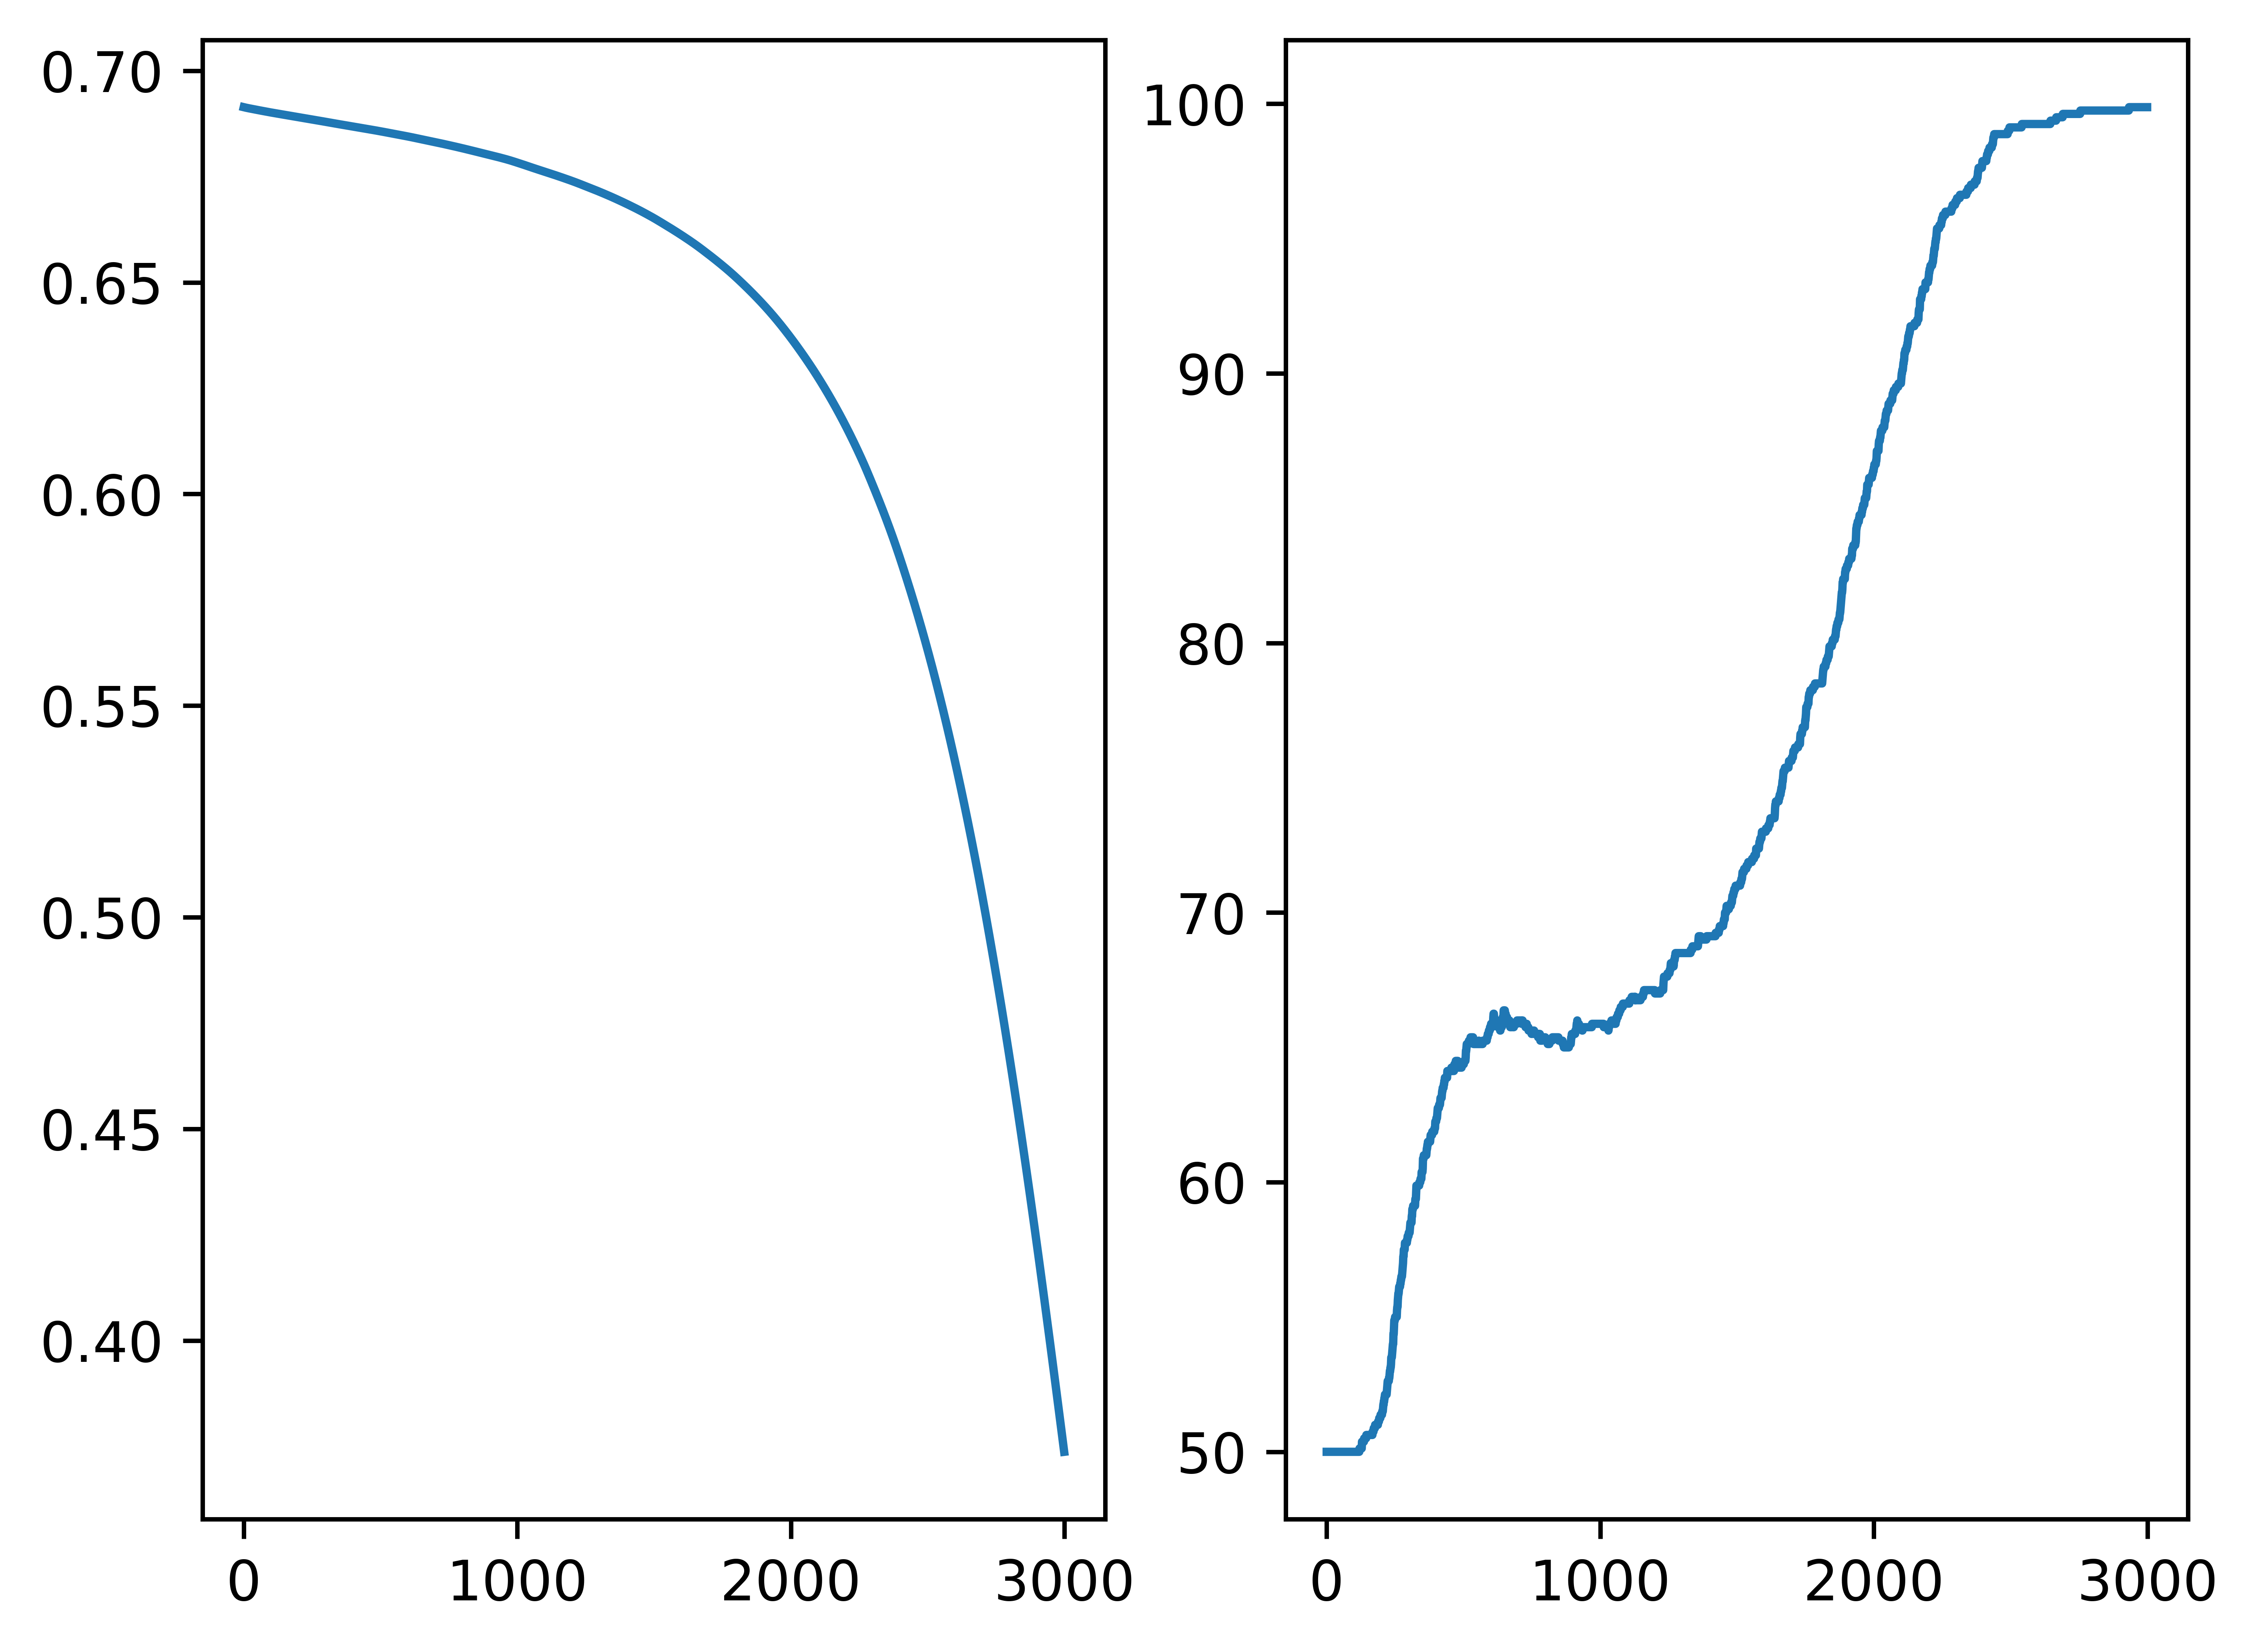

In [16]:
plt.figure(dpi=1000)
plt.subplot(1,2,1)
plt.plot(l)
plt.subplot(1,2,2)
plt.plot(a)
plt.savefig('classification_rev2.png')